Dataset Overview:

   Product ID        Date  Store ID  Sales Quantity  Price Promotions  \
0        4277  2024-01-03        48             330  24.38         No   
1        5540  2024-04-29        10             334  74.98        Yes   
2        5406  2024-01-11        67             429  24.83        Yes   
3        5617  2024-04-04        17             298  13.41         No   
4        3480  2024-12-14        33             344  94.96        Yes   

  Seasonality Factors    External Factors Demand Trend Customer Segments  
0            Festival  Competitor Pricing   Increasing           Regular  
1             Holiday             Weather       Stable           Premium  
2             Holiday  Economic Indicator   Decreasing           Premium  
3                 NaN  Economic Indicator       Stable           Regular  
4            Festival             Weather   Increasing           Regular  

Shape: (10000, 10)

Columns: Index(['Product ID', 'Date', 'Store ID', 'Sales Quantity', 'Pr

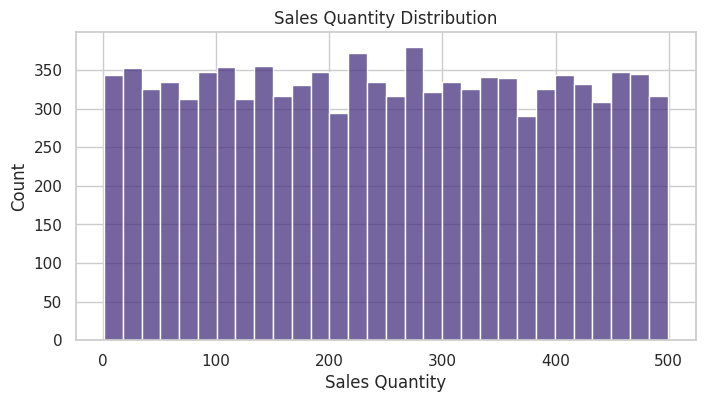

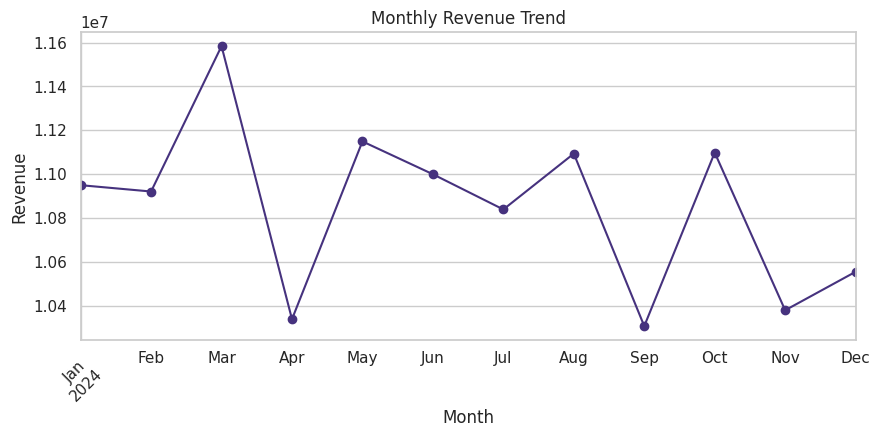

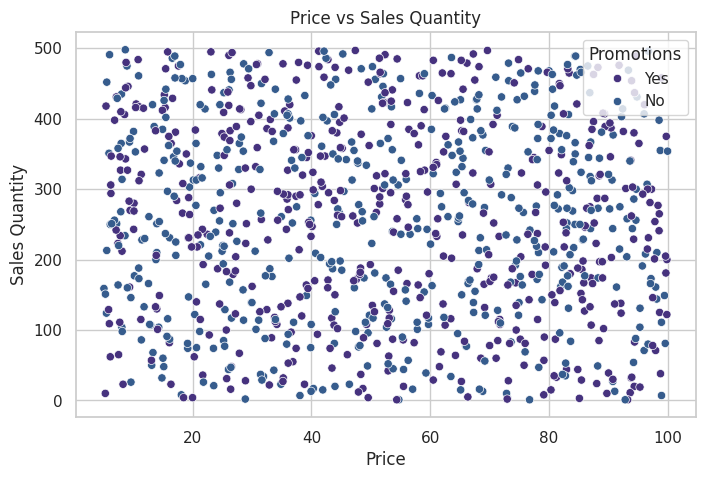


Inventory Metrics:

   Product ID  Avg Daily Demand  Demand Std  Safety Stock  Reorder Point
0        1000        237.333333         NaN           0.0    1661.333333
1        1001        234.333333         NaN           0.0    1640.333333
2        1003        400.000000         NaN           0.0    2800.000000
3        1005        245.000000         NaN           0.0    1715.000000
4        1006        137.000000         NaN           0.0     959.000000

ABC Classification:

   Product ID  Avg Daily Demand  Demand Std  Safety Stock  Reorder Point  \
0        1000        237.333333         NaN           0.0    1661.333333   
1        1001        234.333333         NaN           0.0    1640.333333   
2        1003        400.000000         NaN           0.0    2800.000000   
3        1005        245.000000         NaN           0.0    1715.000000   
4        1006        137.000000         NaN           0.0     959.000000   

    Revenue   Cum_pct ABC_Class  
0  50048.44  0.227616       

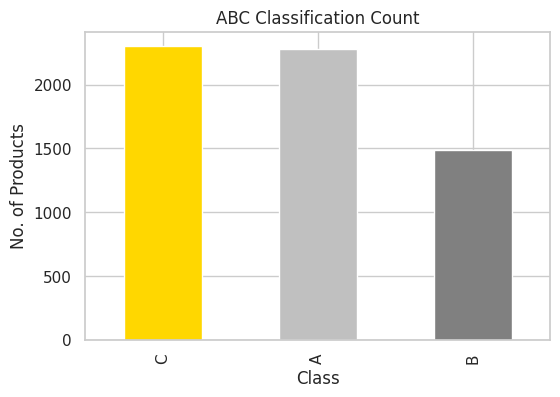


 Key Insights From Inventory Optimization:

Total Products: 6065
A-Class (high revenue): 2276 products → PRIORITY, maintain higher safety stock
B-Class (medium revenue): 1488 products → Balanced inventory
C-Class (low revenue): 2301 products → Reduce stock to cut costs


In [ ]:


# Tools: Python, Pandas, Matplotlib, Seaborn
# ----------------------------------------------------------

#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload Dataset

df = pd.read_csv('/content/demand_forecasting.csv')

# -------------------------------
# INTRO + DATA UNDERSTANDING
# -------------------------------

print("Dataset Overview:\n")
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns)

df.info()

# -------------------------------
#  DATA CLEANING
# -------------------------------

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove missing / invalid date rows
df.dropna(subset=['Date'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("\nMissing Values:\n", df.isna().sum())
print("\nCleaned Data Shape:", df.shape)

# Create new features
df['Revenue'] = df['Sales Quantity'] * df['Price']
df['Month'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year

# -------------------------------
#  EDA: Exploratory Analysis
# -------------------------------

sns.set(style="whitegrid", palette="viridis")

# Sales Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Sales Quantity'], bins=30)
plt.title('Sales Quantity Distribution')
plt.show()

# Revenue by Month
plt.figure(figsize=(10,4))
monthly_rev = df.groupby('Month')['Revenue'].sum()
monthly_rev.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Price vs Sales (Promotions Color)
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price', y='Sales Quantity', hue='Promotions', data=df.sample(1000))
plt.title("Price vs Sales Quantity")
plt.show()

# -------------------------------
#  INVENTORY ANALYSIS
# -------------------------------

# Avg demand per product per store
demand = df.groupby(['Product ID', 'Store ID'])['Sales Quantity'].mean().reset_index()
demand.rename(columns={'Sales Quantity':'Avg Daily Demand'}, inplace=True)

# Demand variability
demand_std = df.groupby(['Product ID', 'Store ID'])['Sales Quantity'].std().reset_index()
demand_std.rename(columns={'Sales Quantity':'Demand Std'}, inplace=True)

metrics = pd.merge(demand, demand_std, on=['Product ID', 'Store ID'])

# Assume 7-day lead time & 95% service level
lead_time = 7
Z = 1.65

metrics['Safety Stock'] = metrics['Demand Std'].fillna(0) * Z * np.sqrt(lead_time)
metrics['Reorder Point'] = metrics['Avg Daily Demand'] * lead_time + metrics['Safety Stock']

# Aggregate by Product
product_inv = metrics.groupby('Product ID').mean()[['Avg Daily Demand','Demand Std','Safety Stock','Reorder Point']]
product_inv.reset_index(inplace=True)

print("\nInventory Metrics:\n")
print(product_inv.head())

# -------------------------------
#  ABC ANALYSIS
# -------------------------------

product_revenue = df.groupby('Product ID')['Revenue'].sum().sort_values(ascending=False)
cum_pct = product_revenue.cumsum() / product_revenue.sum()

ABC = pd.cut(cum_pct, bins=[0,0.7,0.9,1.0], labels=['A','B','C'])

abc_df = pd.DataFrame({
    'Product ID': product_revenue.index,
    'Revenue': product_revenue.values,
    'Cum_pct': cum_pct.values,
    'ABC_Class': ABC.values
})

final_df = pd.merge(product_inv, abc_df, on='Product ID')

print("\nABC Classification:\n")
print(final_df.head())

# Visualization of ABC classes
plt.figure(figsize=(6,4))
abc_df['ABC_Class'].value_counts().plot(kind='bar', color=['gold','silver','gray'])
plt.title("ABC Classification Count")
plt.xlabel("Class")
plt.ylabel("No. of Products")
plt.show()

# -------------------------------
#  BUSINESS INSIGHTS
# -------------------------------

print("\n Key Insights From Inventory Optimization:\n")
total_products = len(final_df)
A = len(final_df[final_df['ABC_Class']=='A'])
B = len(final_df[final_df['ABC_Class']=='B'])
C = len(final_df[final_df['ABC_Class']=='C'])

print(f"Total Products: {total_products}")
print(f"A-Class (high revenue): {A} products → PRIORITY, maintain higher safety stock")
print(f"B-Class (medium revenue): {B} products → Balanced inventory")
print(f"C-Class (low revenue): {C} products → Reduce stock to cut costs")

